# O1 fixed-depth performance across instance-value scales

This notebook compares fixed RF depths 5, 10, 15, and 20 under 0% random-design injection for two O1 landscapes. Ten deterministic instance offsets are sampled with standard deviations 2, 20, 200, 2,000, and 20,000.

In [6]:
from __future__ import annotations
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import t

DEPTHS = (5, 10, 15, 20)
INSTANCE_STDS = (2, 20, 200, 2000, 20000)
BENCHMARK_SEEDS = (40, 41)
SMAC_SEEDS = tuple(range(5))
N_INSTANCES = 10
N_TRIALS = 1000
candidates = [Path.cwd(), Path.cwd() / 'experiments/synthaticBench/o1_deterministic/depth_policies/10_instance_values']
HERE = next((path for path in candidates if (path / 'o1_instance_value_runner.py').exists()), None)
if HERE is None: raise FileNotFoundError('Run from the notebook directory or repository root.')
OUTPUT = HERE / 'smac_output'
print(HERE.resolve())


/rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/10_instance_values


## Load, validate, and audit completeness

In [7]:
rows, curves, instance_maps = [], {}, {}
for path in sorted(OUTPUT.rglob('trajectory.json')):
    data = json.loads(path.read_text())
    benchmark_seed = int(data['benchmark_seed'])
    instance_std = int(data['instance_standard_deviation'])
    depth = int(data['max_depth'])
    smac_seed = int(data['smac_seed'])
    best = np.asarray(data['best_regret'], dtype=float)
    key = (benchmark_seed, instance_std, depth, smac_seed)
    if key in curves:
        raise ValueError(f'Duplicate trajectory: {key}')
    curves[key] = best
    instance_map = tuple(sorted((name, float(value)) for name, value in data['instance_map'].items()))
    if instance_std in instance_maps and instance_maps[instance_std] != instance_map:
        raise ValueError(f'Inconsistent sampled instances for std={instance_std}.')
    instance_maps[instance_std] = instance_map
    rows.append({
        'benchmark_seed': benchmark_seed, 'instance_std': instance_std,
        'depth': depth, 'smac_seed': smac_seed,
        'final_regret': float(best[-1]), 'mean_regret': float(best.mean()),
        'log_auc': float(np.log10(np.maximum(best, 1e-300)).mean()),
        'n_trials': int(data['n_trials']), 'n_instances': int(data['n_instances']),
        'dimension': int(data['dimension']), 'problem_seed': int(data['problem_seed']),
        'instance_mean': float(data['instance_mean']),
        'random_design_probability': float(data['random_design_probability']),
        'pythonhashseed': str(data['pythonhashseed']), 'path': path,
    })
results = pd.DataFrame(rows)
if results.empty:
    raise FileNotFoundError(f'No trajectories found below {OUTPUT}.')
bad = results.query("n_trials != 1000 or n_instances != 10 or dimension != 10 or problem_seed != benchmark_seed or instance_mean != 0 or random_design_probability != 0 or pythonhashseed != '12345'")
if not bad.empty:
    display(bad)
    raise ValueError('Incompatible trajectory metadata.')
expected = {
    (benchmark_seed, instance_std, depth, smac_seed)
    for benchmark_seed in BENCHMARK_SEEDS for instance_std in INSTANCE_STDS
    for depth in DEPTHS for smac_seed in SMAC_SEEDS
}
observed = set(curves)
missing, unexpected = expected - observed, observed - expected
print(f'Loaded {len(observed)}/{len(expected)} trajectories.')
if missing:
    display(pd.DataFrame(sorted(missing), columns=['benchmark_seed', 'instance_std', 'depth', 'smac_seed']))
if unexpected:
    display(pd.DataFrame(sorted(unexpected), columns=['benchmark_seed', 'instance_std', 'depth', 'smac_seed']))
assert not missing and not unexpected
assert set(instance_maps) == set(INSTANCE_STDS)
base_offsets = np.array([value for _, value in instance_maps[INSTANCE_STDS[0]]]) / INSTANCE_STDS[0]
for instance_std in INSTANCE_STDS[1:]:
    scaled = np.array([value for _, value in instance_maps[instance_std]]) / instance_std
    assert np.allclose(scaled, base_offsets)
display(results.groupby(['benchmark_seed', 'instance_std', 'depth']).smac_seed.nunique().unstack(fill_value=0))


Loaded 200/200 trajectories.


depth                        5   10  15  20
benchmark_seed instance_std                
40             2              5   5   5   5
               20             5   5   5   5
               200            5   5   5   5
               2000           5   5   5   5
               20000          5   5   5   5
41             2              5   5   5   5
               20             5   5   5   5
               200            5   5   5   5
               2000           5   5   5   5
               20000          5   5   5   5

## Best-regret trajectories with 95% confidence intervals

Each line is the mean incumbent simple regret over five SMAC seeds. Shaded regions are two-sided 95% Student-t confidence intervals for that mean. All ten panels share logarithmic y-axis limits, so their vertical positions are directly comparable. Rows are landscapes and columns are NumPy normal standard deviations.

Shared trajectory y-limits: (np.float64(558.0750816817897), np.float64(352363.60944505007))


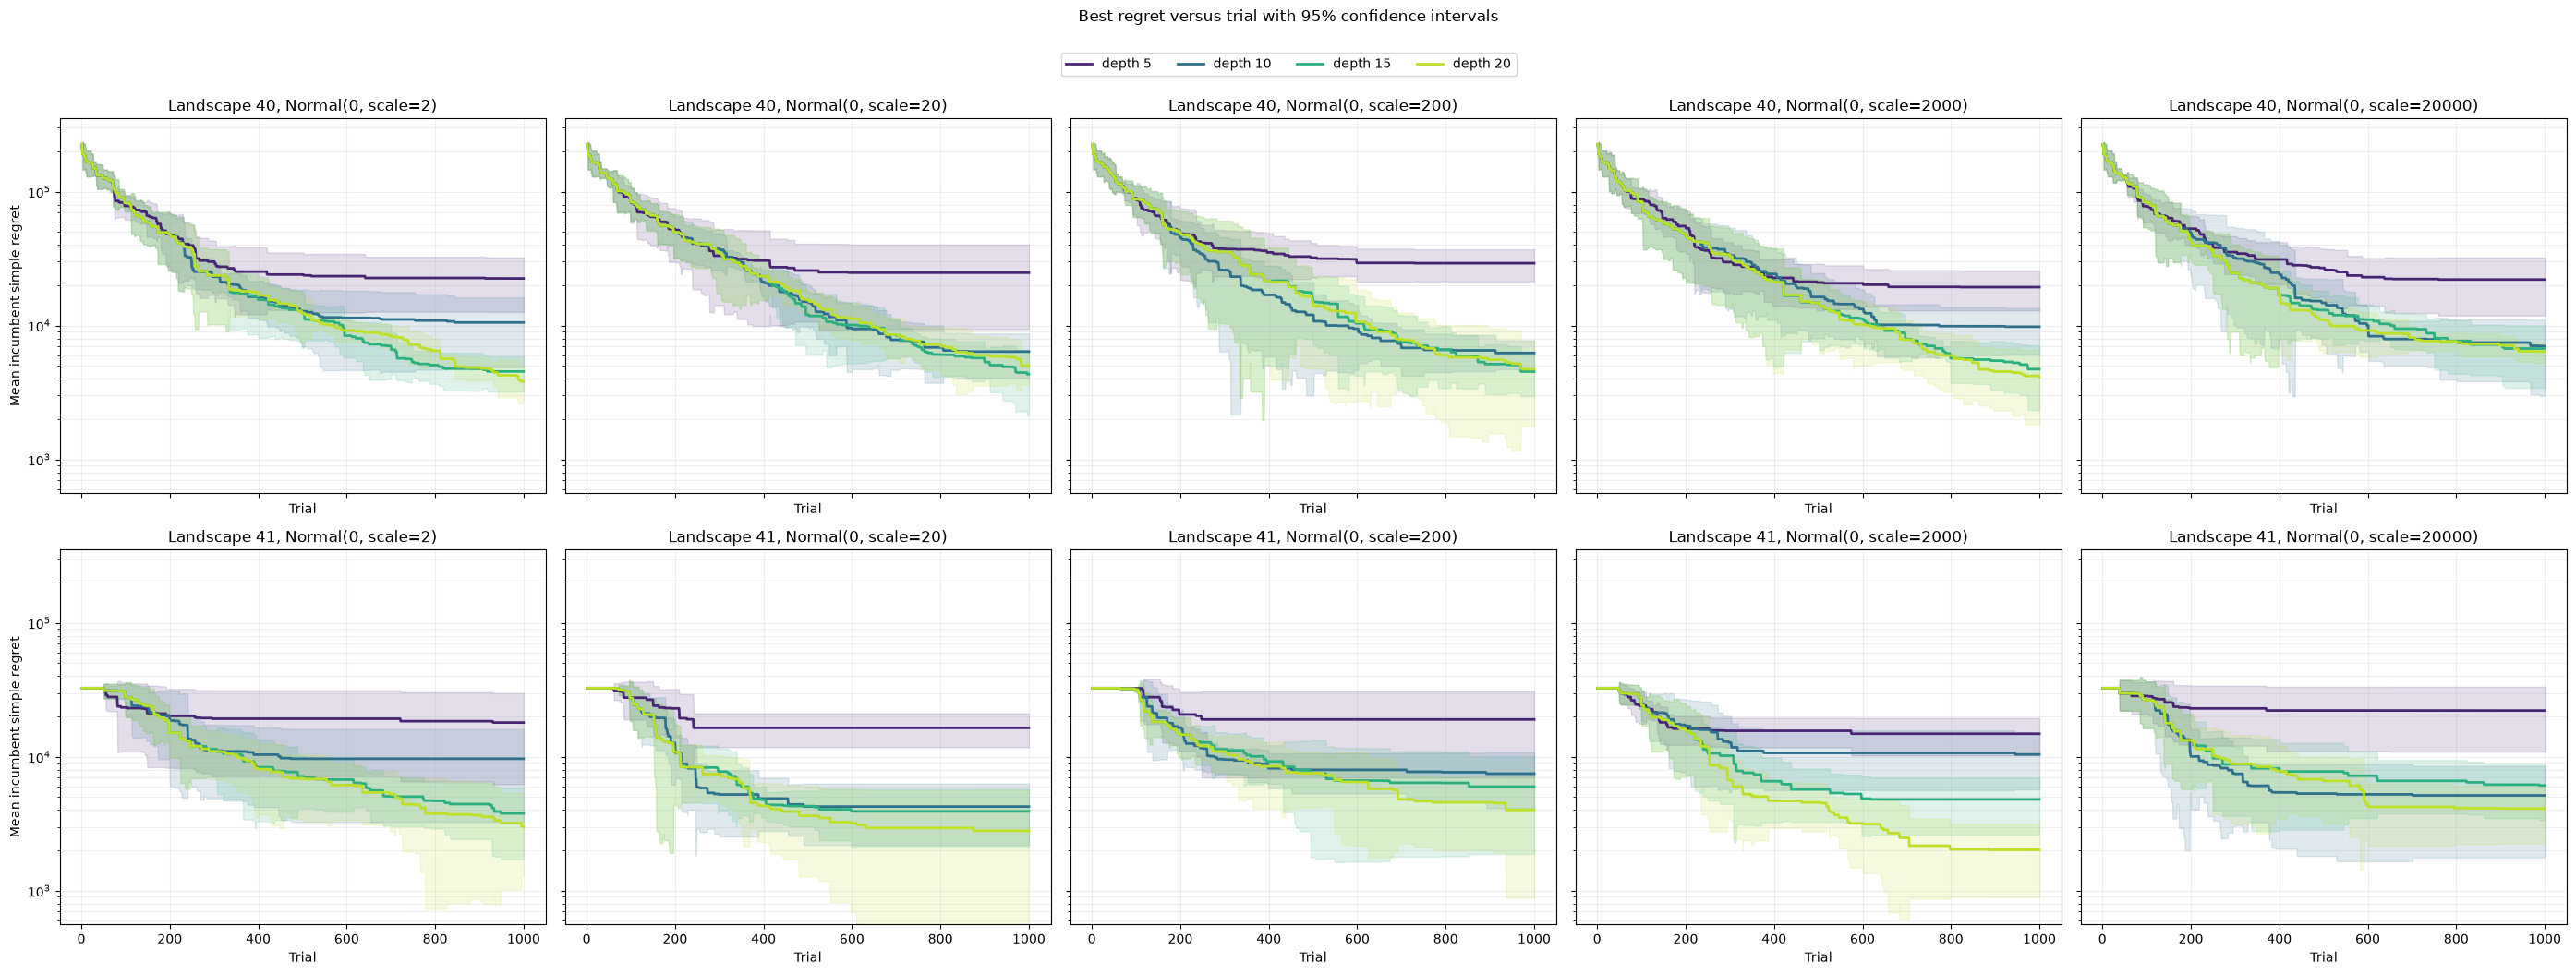

In [8]:
colors = dict(zip(DEPTHS, plt.cm.viridis(np.linspace(.1, .9, len(DEPTHS)))))
x = np.arange(1, N_TRIALS + 1)
def padded_log_limits(values, padding_decades=.08):
    positive = np.concatenate([np.asarray(value, float).ravel() for value in values])
    positive = positive[np.isfinite(positive) & (positive > 0)]
    if not len(positive):
        raise ValueError('Cannot determine logarithmic limits without positive values.')
    low, high = np.log10(positive.min()), np.log10(positive.max())
    padding = max((high - low) * padding_decades, .05)
    return 10 ** (low - padding), 10 ** (high + padding)
trajectory_y_limits = padded_log_limits(list(curves.values()))
print('Shared trajectory y-limits:', trajectory_y_limits)
fig, axes = plt.subplots(len(BENCHMARK_SEEDS), len(INSTANCE_STDS), figsize=(28, 10), sharex=True, sharey=True)
for row, benchmark_seed in enumerate(BENCHMARK_SEEDS):
    for column, instance_std in enumerate(INSTANCE_STDS):
        ax = axes[row, column]
        for depth in DEPTHS:
            matrix = np.vstack([curves[(benchmark_seed, instance_std, depth, seed)] for seed in SMAC_SEEDS])
            mean = matrix.mean(axis=0)
            sem = matrix.std(axis=0, ddof=1) / np.sqrt(len(SMAC_SEEDS))
            margin = t.ppf(.975, len(SMAC_SEEDS) - 1) * sem
            lower = np.maximum(mean - margin, 1e-300)
            upper = np.maximum(mean + margin, 1e-300)
            ax.plot(x, np.maximum(mean, 1e-300), color=colors[depth], lw=2, label=f'depth {depth}')
            ax.fill_between(x, lower, upper, color=colors[depth], alpha=.15)
        ax.set_yscale('log')
        ax.set_ylim(*trajectory_y_limits)
        ax.set_title(f'Landscape {benchmark_seed}, Normal(0, scale={instance_std})')
        ax.set_xlabel('Trial')
        ax.set_ylabel('Mean incumbent simple regret' if column == 0 else '')
        ax.grid(alpha=.2, which='both')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(DEPTHS), bbox_to_anchor=(.5, 1.01))
fig.suptitle('Best regret versus trial with 95% confidence intervals', y=1.05)
fig.tight_layout()
plt.show()


## Final-regret boxplots

Each box contains the five final regrets from the paired SMAC seeds. All ten panels share logarithmic y-axis limits. These final-only limits are separate from the trajectory limits so early-run regret does not compress the boxes. Dots show the individual runs.

Shared final-regret y-limits: (np.float64(641.0149147612419), np.float64(54277.74031044748))


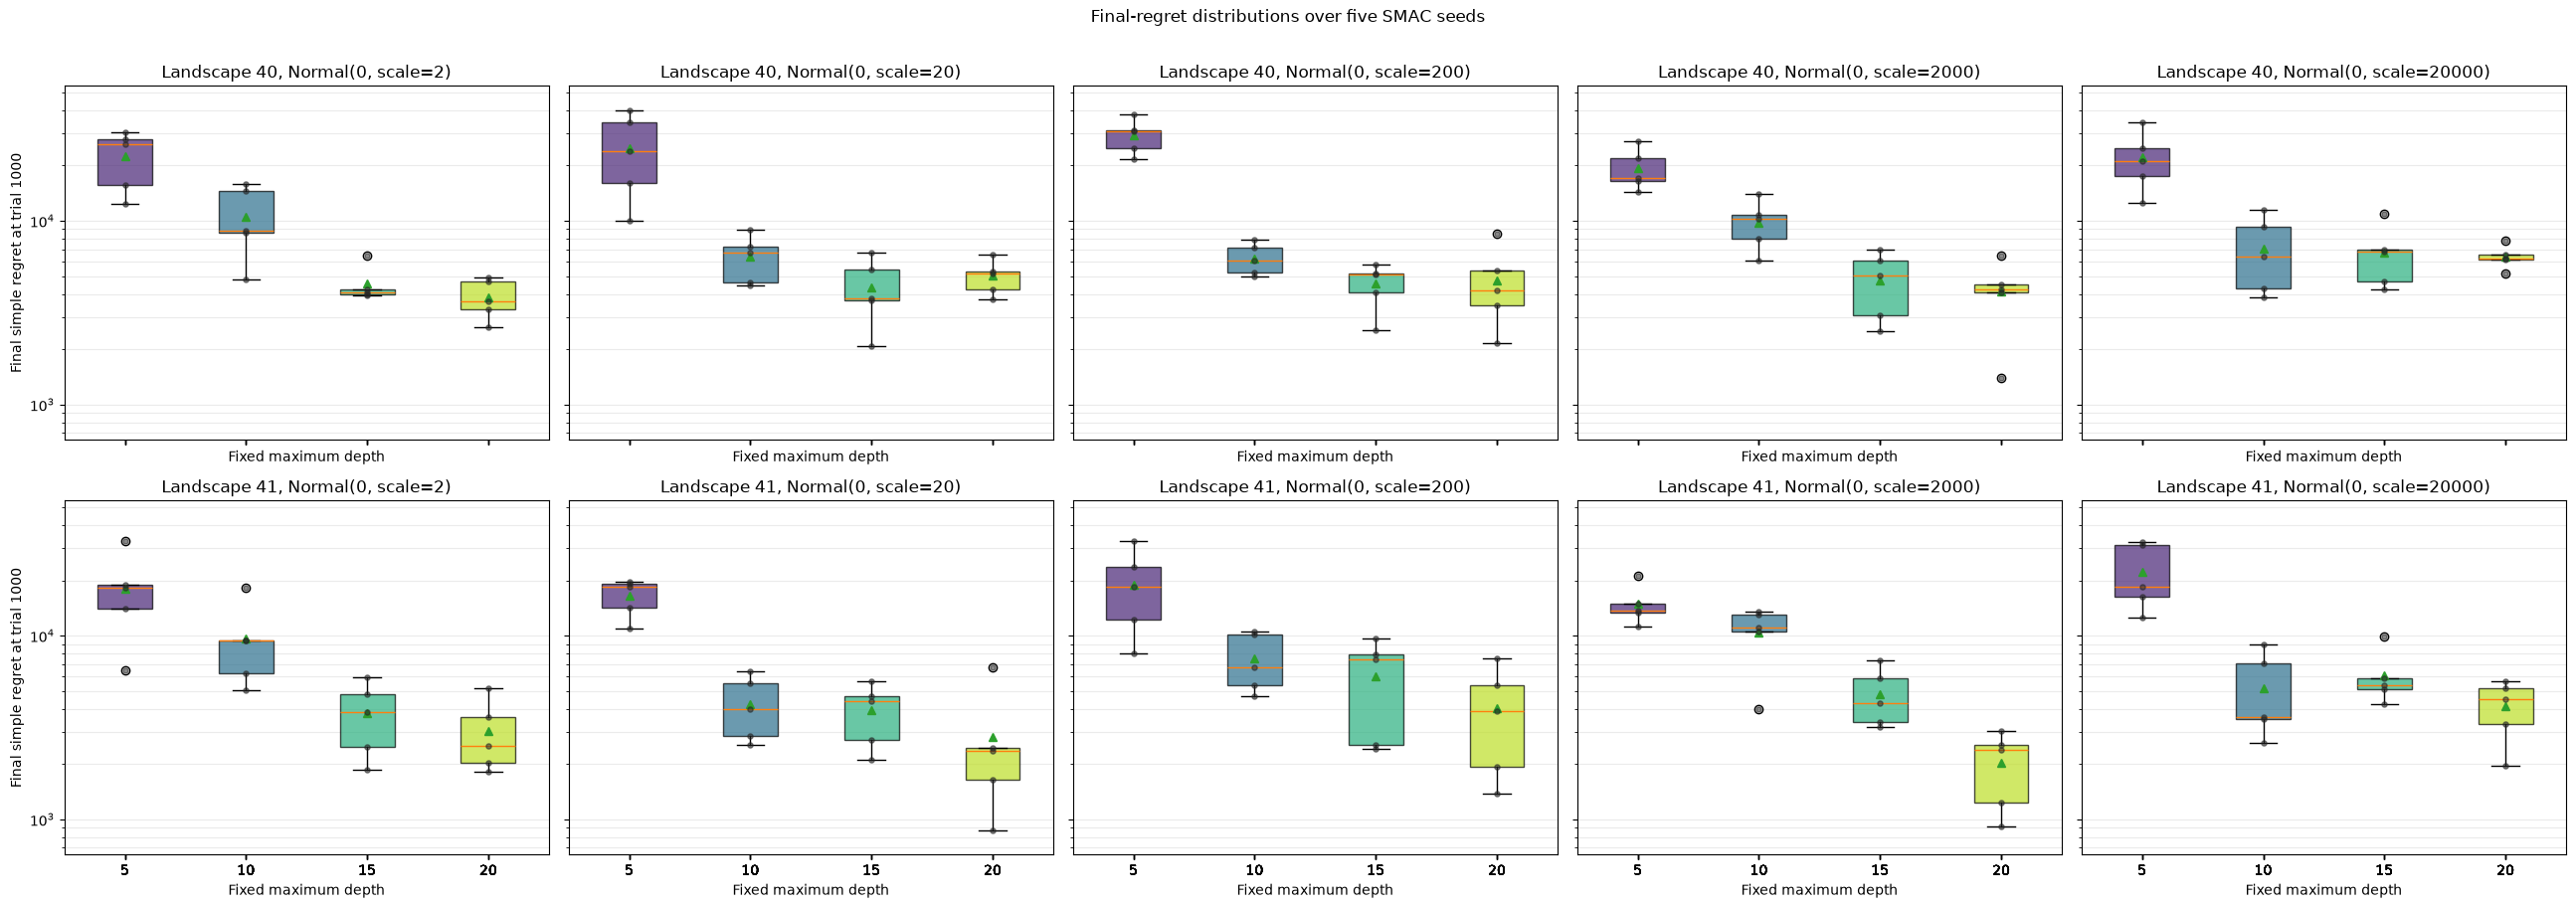

In [9]:
final_y_limits = padded_log_limits([results.final_regret.to_numpy()])
print('Shared final-regret y-limits:', final_y_limits)
fig, axes = plt.subplots(len(BENCHMARK_SEEDS), len(INSTANCE_STDS), figsize=(26, 9), sharex=True, sharey=True)
for row, benchmark_seed in enumerate(BENCHMARK_SEEDS):
    for column, instance_std in enumerate(INSTANCE_STDS):
        ax = axes[row, column]
        subset = results.query('benchmark_seed == @benchmark_seed and instance_std == @instance_std')
        values = [
            subset.query('depth == @depth').sort_values('smac_seed').final_regret.to_numpy()
            for depth in DEPTHS
        ]
        boxes = ax.boxplot(values, tick_labels=[str(depth) for depth in DEPTHS], showmeans=True, patch_artist=True)
        for position, (box, depth, depth_values) in enumerate(zip(boxes['boxes'], DEPTHS, values), start=1):
            box.set_facecolor(colors[depth])
            box.set_alpha(.7)
            ax.scatter(np.full(len(depth_values), position), depth_values, color='0.15', alpha=.55, s=14, zorder=3)
        ax.set_yscale('log')
        ax.set_ylim(*final_y_limits)
        ax.set_xlabel('Fixed maximum depth')
        ax.set_ylabel('Final simple regret at trial 1000' if column == 0 else '')
        ax.set_title(f'Landscape {benchmark_seed}, Normal(0, scale={instance_std})')
        ax.grid(axis='y', alpha=.25, which='both')
fig.suptitle('Final-regret distributions over five SMAC seeds', y=1.01)
fig.tight_layout()
plt.show()


## Numerical summaries

,benchmark_seed,instance_std,depth,runs,mean_final,median_final,std_final,mean_log_auc,mean_regret,rank_within_condition
3,40,2,20,5,3825.493200,3660.974481,944.573803,4.195719,29825.390491,1.0
2,40,2,15,5,4539.239286,4088.406101,1078.240443,4.165491,29335.527435,2.0
1,40,2,10,5,10548.892902,8870.161244,4566.101860,4.278904,31491.861267,3.0
0,40,2,5,5,22492.568287,26065.436631,7930.280026,4.485263,39780.989790,4.0
6,40,20,15,5,4332.183970,3758.953917,1772.640265,4.237397,32409.370545,1.0
7,40,20,20,5,5008.929453,5189.717894,1092.719903,4.269982,33020.267333,2.0
5,40,20,10,5,6391.964437,6701.426825,1878.831075,4.262510,32830.025626,3.0
4,40,20,5,5,24856.982962,23886.231020,12441.560262,4.503843,42117.722895,4.0
10,40,200,15,5,4533.074050,5071.613323,1269.550129,4.234127,33025.410344,1.0
11,40,200,20,5,4728.364220,4198.879292,2386.971990,4.216866,32968.016833,2.0


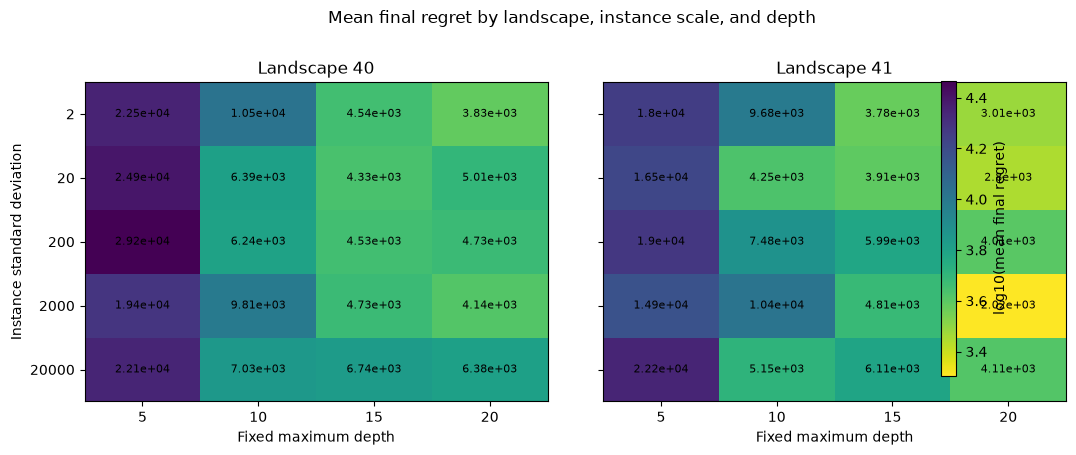

In [10]:
summary = (results.groupby(['benchmark_seed', 'instance_std', 'depth'], as_index=False)
    .agg(runs=('smac_seed','nunique'), mean_final=('final_regret','mean'), median_final=('final_regret','median'),
         std_final=('final_regret','std'), mean_log_auc=('log_auc','mean'), mean_regret=('mean_regret','mean')))
summary['rank_within_condition'] = summary.groupby(['benchmark_seed', 'instance_std']).mean_final.rank(method='average')
display(summary.sort_values(['benchmark_seed', 'instance_std', 'mean_final']))
fig, axes = plt.subplots(1, len(BENCHMARK_SEEDS), figsize=(13, 4.5), sharex=True, sharey=True)
all_means = summary.mean_final.to_numpy()
vmin, vmax = np.log10(all_means.min()), np.log10(all_means.max())
for ax, benchmark_seed in zip(axes, BENCHMARK_SEEDS):
    mean_heatmap = (summary.query('benchmark_seed == @benchmark_seed')
                    .pivot(index='instance_std', columns='depth', values='mean_final')
                    .reindex(index=INSTANCE_STDS, columns=DEPTHS))
    image = ax.imshow(np.log10(mean_heatmap), aspect='auto', cmap='viridis_r', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(DEPTHS)), DEPTHS)
    ax.set_yticks(range(len(INSTANCE_STDS)), INSTANCE_STDS)
    ax.set_xlabel('Fixed maximum depth')
    ax.set_ylabel('Instance standard deviation' if ax is axes[0] else '')
    ax.set_title(f'Landscape {benchmark_seed}')
    for row in range(len(INSTANCE_STDS)):
        for column in range(len(DEPTHS)):
            ax.text(column, row, f'{mean_heatmap.iloc[row, column]:.3g}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=axes, label='log10(mean final regret)', shrink=.85)
fig.suptitle('Mean final regret by landscape, instance scale, and depth')
fig.subplots_adjust(top=.82, right=.88, wspace=.12)
plt.show()


## Interpretation notes

- Compare which fixed depth is best at each instance scale and whether the ordering changes by landscape.
- Look for scales where fixed depths separate clearly relative to their confidence bands and seed variance.
- Confidence intervals contain only five SMAC seeds and should be treated as descriptive.
- Because each scale uses the same standardized draws, changes are easier to attribute to offset magnitude rather than unrelated instance samples.